In [5]:

import re
import numpy as np


def createDictionary(filename):
    priority_dict = {'HIGH': [], 'MID': [],'LOW':[]}
    # Open and read the file
    with open(filename, 'r') as file:
        # Read the entire content
        content = file.read()
        
        # Regular expression to match request patterns
        pattern = r"requestID : (test_\d+) - Priority : (\d+) - time : (\d+\.\d+)"
        
        # Find all matches
        matches = re.findall(pattern, content)
        
        # Process each match
        for request_id, priority, time in matches:
            if priority == '0':
                priority_dict['HIGH'].append(float(time))
            elif priority == '5':
                priority_dict['MID'].append(float(time))
            elif priority == '10':
                priority_dict['LOW'].append(float(time))
        return priority_dict

filename1 = '2mode_woLC_wP_wCB.txt'
filename2 = '2mode_wLC_wP_wCB.txt'
filename3 = 'beforeCoreBind/2mode_wLC_wPreemption.txt'
filename4 = 'beforeCoreBind/2mode_woLC_wPreemption.txt'
# filename1 = 'afterCoreBind/3mode_wLC_wPreemption_C.txt'
# filename2 = 'afterCoreBind/3mode_woLC_wPreemption_C.txt'

filename5 = '3mode_wLC_woP_wCB.txt'
filename6 = '3mode_woLC_woP_wCB.txt'
# filename5 = 'beforeCoreBind/3mode_woLC_woPreemption.txt'
# filename6 = 'beforeCoreBind/3mode_wLC_woPreemption.txt'

# Print the result
target_wLengthControl_C = createDictionary(filename1)
target_woLengthControl_C = createDictionary(filename2)
target_wLengthControl = createDictionary(filename3)
target_woLengthControl = createDictionary(filename4)

base_wLengthControl = createDictionary(filename5)
base_woLengthControl = createDictionary(filename6)
print(target_wLengthControl['MID'])
print(target_woLengthControl['MID'])
print(base_wLengthControl['MID'])
print(base_woLengthControl['MID'])

[]
[]
[1109.013804, 1098.288102, 1098.423652, 1097.847326, 1098.497031, 1098.346588, 1098.266531, 1098.259334, 1097.60532, 1097.305238, 1106.35798, 1097.677361, 1097.746871, 1097.529337, 1098.349184, 1097.999425, 1097.962769, 1097.408682, 1097.967562, 1098.25597]
[4717.141573, 4717.68835, 4717.292404, 4716.328632, 4718.409364, 4718.097987, 4718.500933, 4717.645866, 4717.103886, 4718.311601, 4717.670764, 4718.698118, 4718.981844, 4718.457468, 4719.502534, 4718.262084, 4719.164837, 4717.528219, 4718.822695, 4718.27694]


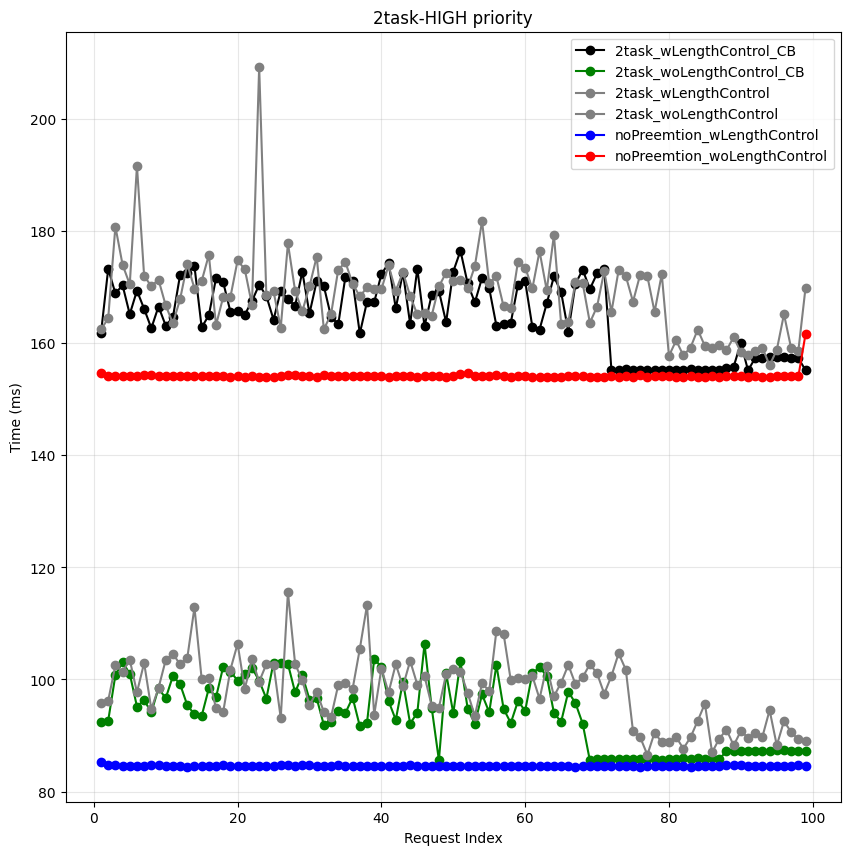

In [6]:
import matplotlib.pyplot as plt
target_wLengthControl_times = target_wLengthControl['HIGH'][1:]
target_woLengthControl_times = target_woLengthControl['HIGH'][1:]
target_wLengthControl_C_times = target_wLengthControl_C['HIGH'][1:]
target_woLengthControl_C_times = target_woLengthControl_C['HIGH'][1:]
base_wLengthControl_times = base_wLengthControl['HIGH'][1:]
base_woLengthControl_times = base_woLengthControl['HIGH'][1:]

# Creating x-axis values for each category
x_high = list(range(1, len(target_wLengthControl_times) + 1))

# Plotting the data
plt.figure(figsize=(10, 10))
if target_wLengthControl_C_times:
    plt.plot(x_high, target_wLengthControl_C_times, marker='o', color='black', label='2task_wLengthControl_CB')
if target_woLengthControl_C_times:
    plt.plot(x_high, target_woLengthControl_C_times, marker='o', color='green', label='2task_woLengthControl_CB')

if target_wLengthControl_times:
    plt.plot(x_high, target_wLengthControl_times, marker='o', color='grey', label='2task_wLengthControl')
if target_woLengthControl_times:
    plt.plot(x_high, target_woLengthControl_times, marker='o', color='grey', label='2task_woLengthControl')
if base_wLengthControl_times:
    plt.plot(x_high, base_wLengthControl_times[:len(target_wLengthControl_times)], marker='o', color='blue', label='noPreemtion_wLengthControl')
if base_woLengthControl_times:
    plt.plot(x_high, base_woLengthControl_times[:len(target_wLengthControl_times)], marker='o', color='red', label='noPreemtion_woLengthControl')


# Adding labels and styling
plt.title('2task-HIGH priority')
plt.xlabel('Request Index')
plt.ylabel('Time (ms)')
plt.grid(True, alpha=0.3)
plt.legend()

# Display the plot
plt.show()